In [ ]:
import os
from copy import deepcopy
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from pyhere import here
from rich.progress import track
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from torch_geometric.loader import DataLoader
from tqdm import tqdm, trange

from bk_buster.generator.node_binary import (
    generate_data,
    make_graph,
    make_graphs_nx,
    visualize_graph,
)
from bk_buster.model.synthetic import (
    GAT,
    GCN,
    MLP,
    gat_test,
    gat_train,
    gcn_test,
    gcn_train,
    mlp_test,
    mlp_train,
)
from bk_buster.perturb import add_random_edges
from bk_buster.utils.plot import set_plot_params, set_size

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [3]:
def run_baselines(X, y, num_graphs, device, seed):

    # for uninformed models that do not use graph structure, we can precompute once
    train_mask, test_mask = train_test_split(np.arange(num_graphs), test_size=0.2, random_state=seed)
    data_list = [make_graph(x, y) for x, y in zip(X, y)]
    train_loader = DataLoader([data_list[i] for i in train_mask], batch_size=32, shuffle=True)
    test_loader = DataLoader([data_list[i] for i in test_mask], batch_size=1, shuffle=False)

    # LogReg
    model = LogisticRegression()
    X_flat_train = X[train_mask].flatten().reshape(-1, 1)
    y_flat_train = y[train_mask].flatten()
    X_flat_test = X[test_mask].flatten().reshape(-1, 1)
    y_flat_test = y[test_mask].flatten()
    model.fit(X_flat_train, y_flat_train)
    logreg_acc = model.score(X_flat_test, y_flat_test)
    # print(f"LogReg accuracy: {logreg_acc}")

    # SVM
    model = SVC()
    model.fit(X_flat_train, y_flat_train)
    svm_acc = model.score(X_flat_test, y_flat_test)
    # print(f"SVM accuracy: {svm_acc}")

    # MLP
    model = MLP(input_dim=1, hidden_dim=8, output_dim=2).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    num_epochs = 200
    for epoch in range(1, num_epochs+1):
        loss = mlp_train(model, train_loader, optimizer, criterion, device)
    mlp_acc = mlp_test(model, test_loader, device)
    # print(f"MLP accuracy: {mlp_acc}")

    return {
        "logreg_acc": logreg_acc,
        "svm_acc": svm_acc,
        "mlp_acc": mlp_acc,
    }

def run_gnns(data_list, num_graphs, device, seed):

    # split data
    train_mask, test_mask = train_test_split(np.arange(num_graphs), test_size=0.2, random_state=seed)
    train_loader = DataLoader([data_list[i] for i in train_mask], batch_size=32, shuffle=True)
    test_loader = DataLoader([data_list[i] for i in test_mask], batch_size=1, shuffle=False)

    # GCN
    model = GCN(input_dim=1, hidden_dim=8, output_dim=2).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    num_epochs = 200
    for epoch in range(1, num_epochs+1):
        loss = gcn_train(model, train_loader, optimizer, criterion, device)
    gcn_acc = gcn_test(model, test_loader, device)
    # results.append({"run_idx": run_idx, "alg": "GCN", "acc": gcn_acc, "informed": True, "kappa": kappa})

    # GAT
    model = GAT(input_dim=1, hidden_dim=8, output_dim=2, heads=4).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    num_epochs = 200
    for epoch in range(1, num_epochs+1):
        loss = gat_train(model, train_loader, optimizer, criterion, device)
    gat_acc = gat_test(model, test_loader, device)
    # results.append({"run_idx": run_idx, "alg": "GAT", "informed": True, "acc": gat_acc, "kappa": kappa})

    return {
        "gcn_acc": gcn_acc,
        "gat_acc": gat_acc,
    }

def auc_from_group(g, x_col, y_col):
    x = g[x_col].values
    y = g[y_col].values
    # sort to be safe
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]
    return np.trapezoid(y, x) / (x.max() - x.min())

## Data

In [4]:
# medium overlap
g1_dist_params = (0.45, 0.1)
g2_dist_params = (0.55, 0.1)
num_nodes_per_class = 10
num_graphs = 100
existing_edges = list(combinations(range(0, num_nodes_per_class), 2)) + list(combinations(range(num_nodes_per_class, num_nodes_per_class*2), 2))
n_edges = len(existing_edges)
existing_nodes = list(range(0, num_nodes_per_class*2))
n_nodes = len(existing_nodes)
rng = np.random.default_rng(42)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42)

Using device: cuda:0


In [5]:
markers_alg = {
    "GAT": "o",
    "GCN": "o",
    "MLP": ",",
    "SVM": ",",
    "LogReg": ",",
}

dashes_alg = {
    "GAT": "",
    "GCN": "",
    "MLP": (2, 2),
    "SVM": (2, 2),
    "LogReg": (2, 2),
}

colors_alg = {
    "GAT": sns.color_palette("deep")[0],
    "GCN": sns.color_palette("deep")[1],
    "MLP": sns.color_palette("deep")[2],
    "SVM": sns.color_palette("deep")[3],
    "LogReg": sns.color_palette("deep")[4],
}

## Removing Edges

In [6]:
results = []
for run_idx in trange(10, desc="Runs"):

    X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42+run_idx)

    baseline_results = run_baselines(X, y, num_graphs, device, seed=42+run_idx)

    for kappa in np.arange(0, 1.01, 0.1):

        num_edges_to_remove = int(kappa * n_edges)
        edges_to_remove = rng.choice(existing_edges, size=num_edges_to_remove, replace=False)
        edge_ops = [["remove", src, dst] for src, dst in edges_to_remove]
        data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

        # run GNNs
        gnns_results = run_gnns(data_list, num_graphs, device, seed=42+run_idx)
        results.append({"run_idx": run_idx, "alg": "GCN", "informed": True, "acc": gnns_results["gcn_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "GAT", "informed": True, "acc": gnns_results["gat_acc"], "kappa": kappa})

        # add uninformed models to make plotting easier
        results.append({"run_idx": run_idx, "alg": "LogReg", "informed": False, "acc": baseline_results["logreg_acc"],"kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "SVM", "informed": False, "acc": baseline_results["svm_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "MLP", "informed": False, "acc": baseline_results["mlp_acc"], "kappa": kappa})

res_rem_df = pd.DataFrame.from_records(results)

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Runs: 100%|██████████| 10/10 [41:27<00:00, 248.77s/it]


In [7]:
# save results
res_rem_df.to_csv("syn_node_rem_edges.csv", index=False)

# load results
res_rem_df = pd.read_csv("syn_node_rem_edges.csv")

In [8]:
# compute AUC per (alg, run)
auc_df = (
    res_rem_df.groupby(["alg", "run_idx"])
          [["kappa", "acc"]]
          .apply(auc_from_group, x_col="kappa", y_col="acc")
          .reset_index(name="auc")
)

# now average across runs of same algorithm
final_auc = auc_df.groupby("alg")["auc"].mean()

display(final_auc)

alg
GAT       0.88490
GCN       0.88085
LogReg    0.70350
MLP       0.70150
SVM       0.70225
Name: auc, dtype: float64

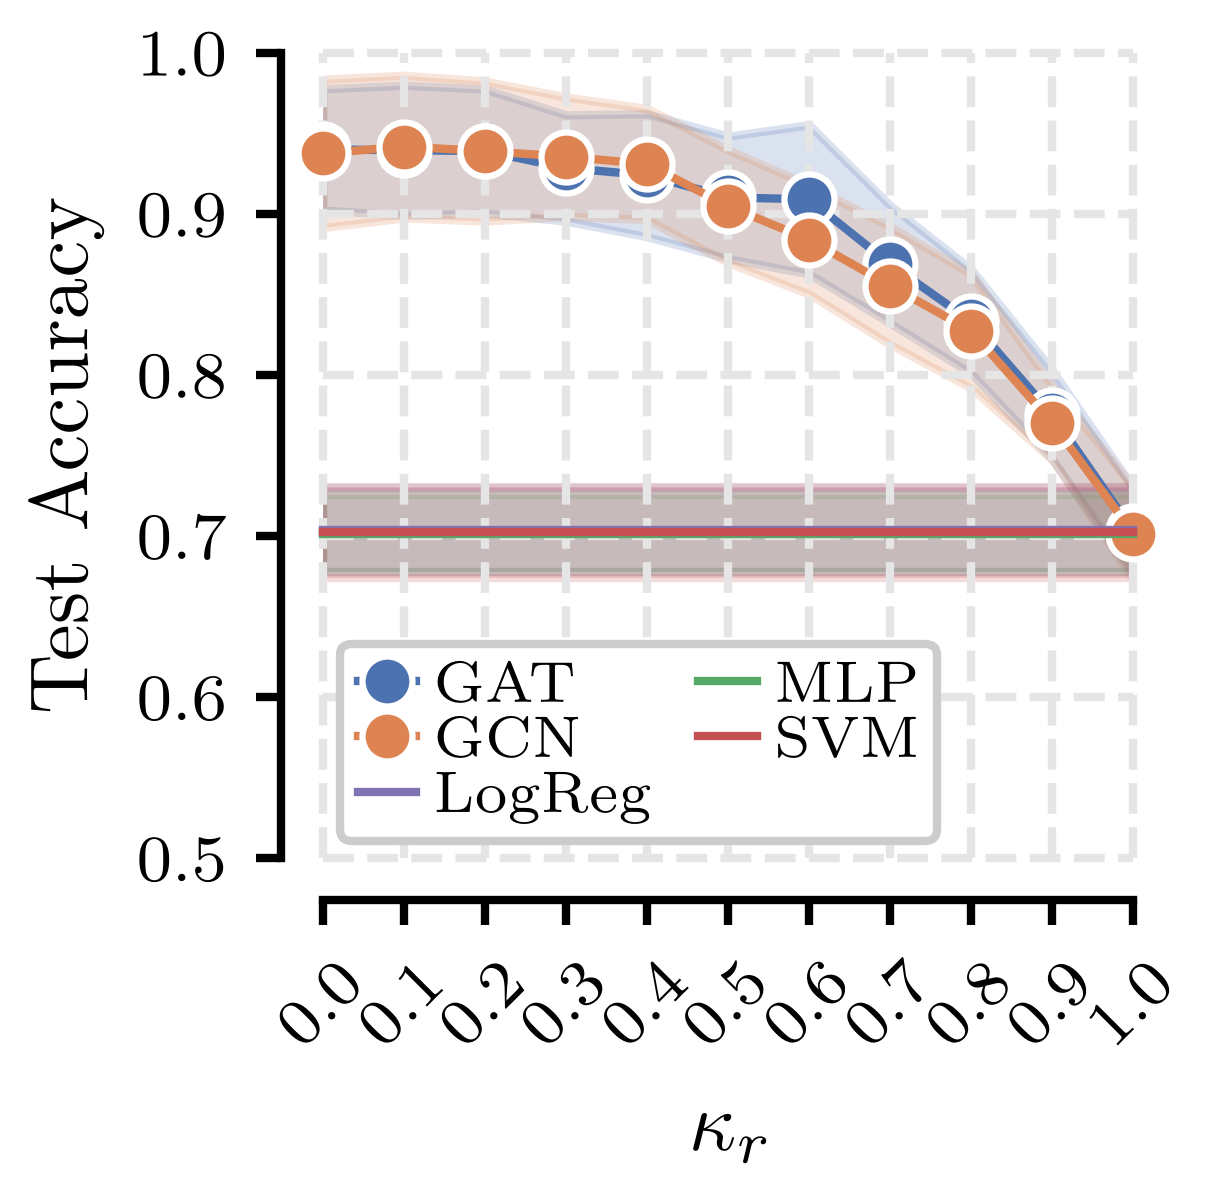

In [9]:
set_plot_params(style_name="pub_ltx")
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(1,1, figsize=set_size("ieee_1c", aspect_ratio=1, fraction=0.5))

sns.lineplot(
    data=res_rem_df.sort_values(by=["alg", "kappa"], ascending=True),
    x="kappa",
    y="acc",
    hue="alg",
    palette=colors_alg,
    style="alg",
    markers=markers_alg,
    markersize=6,
    dashes=False,
    errorbar="sd",
    clip_on=False,
    alpha=1.0,
    ax=ax
)

ax.set_xlabel("$\\kappa_{r}$")
ax.set_xlim(0, 1.0)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

leg = ax.legend(
    loc="lower left",
    framealpha=1.0,
    borderaxespad=0.3,
    borderpad=0.3,
    labelspacing=0.05,
    ncol=2,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=0.8,
)
for text in leg.get_texts():
    if text.get_text() == "alg":
        text.set_text("Method")
    if text.get_text() in ["Method", "informed"]:
        # text.set_fontweight("bold")
        text.set_text(r"\textbf{" + text.get_text().capitalize() + "}")

# despine
sns.despine(offset=5, trim=True)
for gl in ax.get_xgridlines() + ax.get_ygridlines():
    gl.set_clip_on(False)
    gl.set_in_layout(False)

fig.savefig("syn_node_rem_edges.pdf", bbox_inches="tight", pad_inches=0)

plt.show()

## Adding Edges

In [22]:
extra_edges = []
for i in range(10):
    for j in range(10, 20):
        if i != j:
            extra_edges.append(["add", i, j])

results = []
for run_idx in trange(10, desc="Runs"):

    X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42+run_idx)

    baseline_results = run_baselines(X, y, num_graphs, device, seed=42+run_idx)

    for kappa in np.arange(0, 1.01, 0.1):

        extra_edge_count = int(kappa * n_edges)
        edge_ops = rng.choice(extra_edges, size=extra_edge_count, replace=False)
        data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

        # run GNNs
        gnns_results = run_gnns(data_list, num_graphs, device, seed=42+run_idx)
        results.append({"run_idx": run_idx, "alg": "GCN", "informed": True, "acc": gnns_results["gcn_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "GAT", "informed": True, "acc": gnns_results["gat_acc"], "kappa": kappa})

        # add uninformed models to make plotting easier
        results.append({"run_idx": run_idx, "alg": "LogReg", "informed": False, "acc": baseline_results["logreg_acc"],"kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "SVM", "informed": False, "acc": baseline_results["svm_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "MLP", "informed": False, "acc": baseline_results["mlp_acc"], "kappa": kappa})

res_add_df = pd.DataFrame.from_records(results)

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Runs: 100%|██████████| 10/10 [04:24<00:00, 26.45s/it]


In [23]:
# save results
res_add_df.to_csv("syn_node_add_edges.csv", index=False)

# load results
res_add_df = pd.read_csv("syn_node_add_edges.csv")

In [24]:
# compute AUC per (alg, run)
auc_df = (
    res_add_df.groupby(["alg", "run_idx"])
          [["kappa", "acc"]]
          .apply(auc_from_group, x_col="kappa", y_col="acc")
          .reset_index(name="auc")
)

# now average across runs of same algorithm
final_auc = auc_df.groupby("alg")["auc"].mean()

display(final_auc)

alg
GAT       0.708225
GCN       0.688100
LogReg    0.703500
MLP       0.701500
SVM       0.702250
Name: auc, dtype: float64

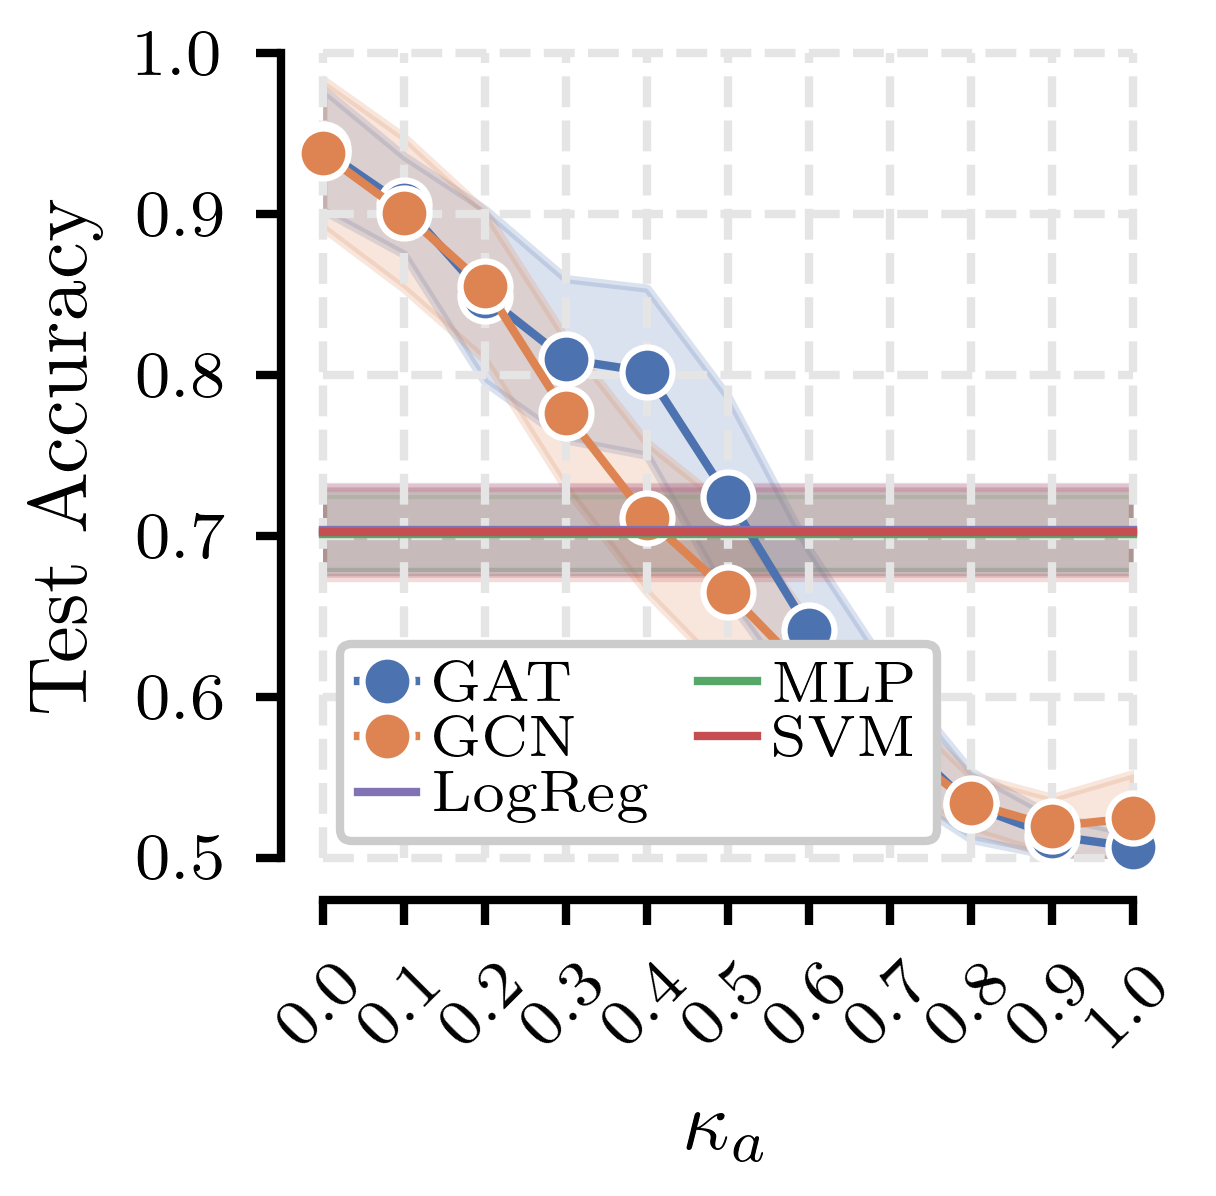

In [26]:
set_plot_params(style_name="pub_ltx")
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(1,1, figsize=set_size("ieee_1c", aspect_ratio=1, fraction=0.5))

sns.lineplot(
    data=res_add_df.sort_values(by=["alg", "kappa"], ascending=True),
    x="kappa",
    y="acc",
    hue="alg",
    palette=colors_alg,
    style="alg",
    markers=markers_alg,
    markersize=6,
    dashes=False,
    errorbar="sd",
    clip_on=False,
    ax=ax
)

ax.set_xlabel("$\\kappa_{a}$")
ax.set_xlim(0, 1.0)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

leg = ax.legend(
    loc="lower left",
    framealpha=1.0,
    borderaxespad=0.3,
    borderpad=0.3,
    labelspacing=0.05,
    ncol=2,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=0.8,
)
for text in leg.get_texts():
    if text.get_text() == "alg":
        text.set_text("Method")
    if text.get_text() in ["Method", "informed"]:
        # text.set_fontweight("bold")
        text.set_text(r"\textbf{" + text.get_text().capitalize() + "}")

# despine
sns.despine(offset=5, trim=True)
for gl in ax.get_xgridlines() + ax.get_ygridlines():
    gl.set_clip_on(False)
    gl.set_in_layout(False)

fig.savefig("syn_node_add_edges.pdf", bbox_inches="tight", pad_inches=0)

plt.show()

## Isolate Nodes

In [36]:
results = []
for run_idx in trange(10, desc="Runs"):

    X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42+run_idx)

    baseline_results = run_baselines(X, y, num_graphs, device, seed=42+run_idx)

    for num_nodes_to_isolate in range(0, n_nodes, 1):

        kappa = num_nodes_to_isolate / n_nodes
        edges_to_remove = []
        nodes_to_isolate = rng.choice(existing_nodes, size=num_nodes_to_isolate, replace=False)
        for node_to_isolate in nodes_to_isolate:
            edges_to_remove.extend([(u, v) for u, v in existing_edges if u == node_to_isolate or v == node_to_isolate])
        edge_ops = [["remove", src, dst] for src, dst in edges_to_remove]
        data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

        # run GNNs
        gnns_results = run_gnns(data_list, num_graphs, device, seed=42+run_idx)
        results.append({"run_idx": run_idx, "alg": "GCN", "informed": True, "acc": gnns_results["gcn_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "GAT", "informed": True, "acc": gnns_results["gat_acc"], "kappa": kappa})

        # add uninformed models to make plotting easier
        results.append({"run_idx": run_idx, "alg": "LogReg", "informed": False, "acc": baseline_results["logreg_acc"],"kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "SVM", "informed": False, "acc": baseline_results["svm_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "MLP", "informed": False, "acc": baseline_results["mlp_acc"], "kappa": kappa})

res_iso_df = pd.DataFrame.from_records(results)

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Runs: 100%|██████████| 10/10 [08:01<00:00, 48.12s/it]


In [ ]:
# save results
res_iso_df.to_csv("syn_node_iso_nodes.csv", index=False)

# load results
res_iso_df = pd.read_csv("syn_node_iso_nodes.csv")

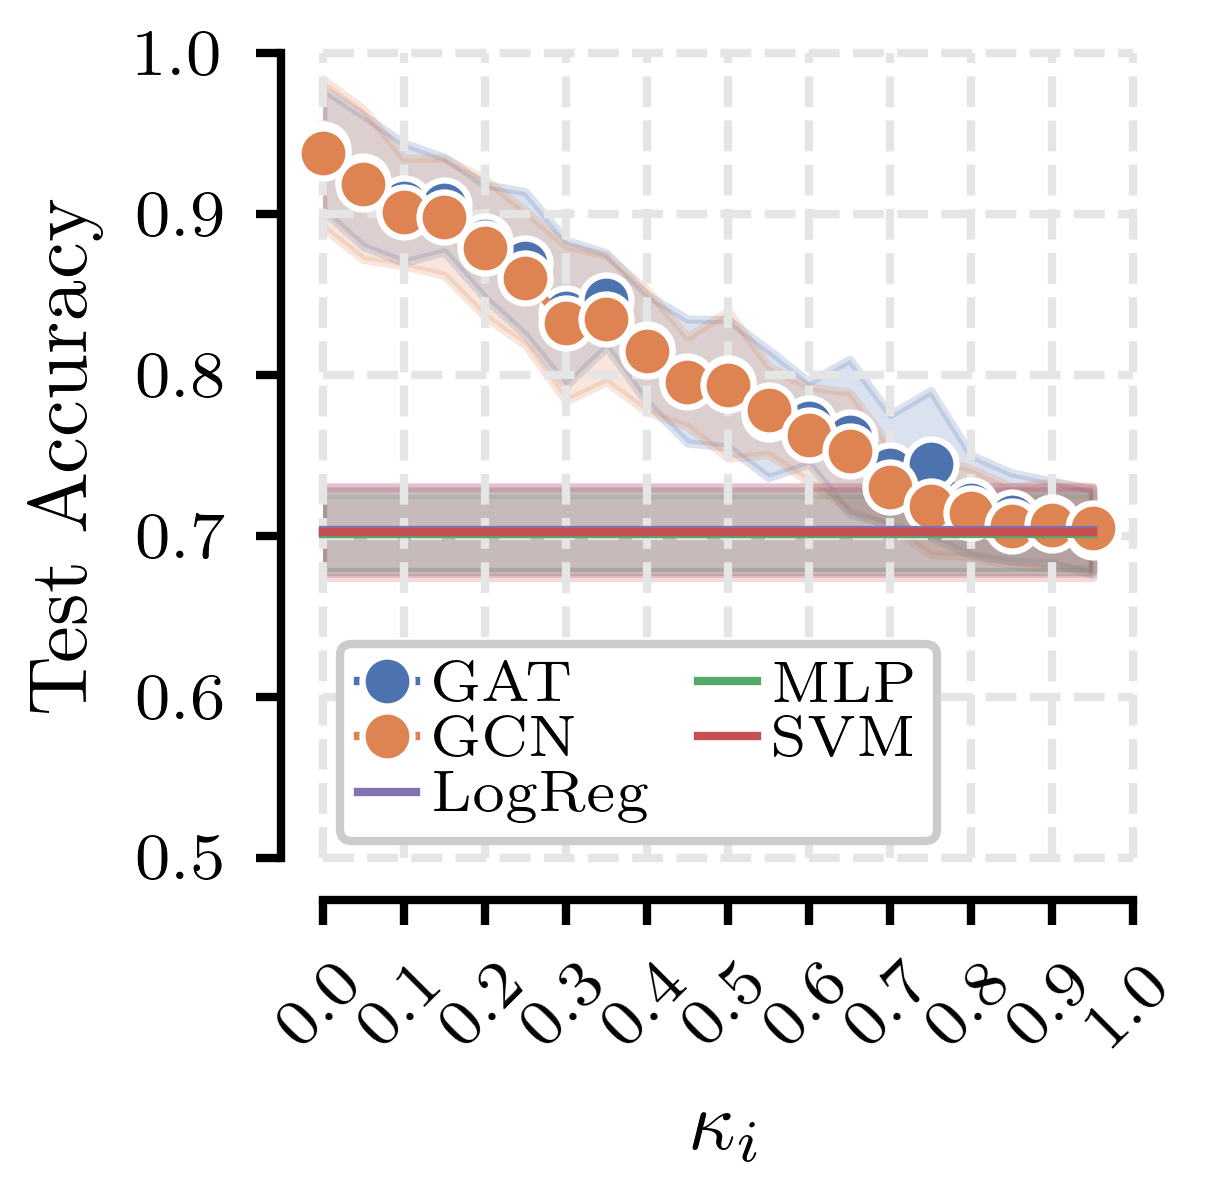

In [7]:
set_plot_params(style_name="pub_ltx")
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(1,1, figsize=set_size("ieee_1c", aspect_ratio=1, fraction=0.5))

sns.lineplot(
    data=res_iso_df.sort_values(by=["alg", "kappa"], ascending=True),
    x="kappa",
    y="acc",
    hue="alg",
    palette=colors_alg,
    style="alg",
    markers=markers_alg,
    markersize=6,
    dashes=False,
    errorbar="sd",
    clip_on=False,
    ax=ax
)

ax.set_xlabel("$\\kappa_{i}$")
ax.set_xticks(res_iso_df["kappa"].unique())
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

leg = ax.legend(
    loc="lower left",
    framealpha=1.0,
    borderaxespad=0.3,
    borderpad=0.3,
    labelspacing=0.05,
    ncol=2,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=0.8,
)
for text in leg.get_texts():
    if text.get_text() == "alg":
        text.set_text("Method")
    if text.get_text() in ["Method", "informed"]:
        # text.set_fontweight("bold")
        text.set_text(r"\textbf{" + text.get_text().capitalize() + "}")

# despine
sns.despine(offset=5, trim=True)
for gl in ax.get_xgridlines() + ax.get_ygridlines():
    gl.set_clip_on(False)
    gl.set_in_layout(False)

fig.savefig("syn_node_iso_nodes.pdf", bbox_inches="tight", pad_inches=0)

plt.show()

## Detach-and-Rewire

In [42]:
results = []
for run_idx in trange(10, desc="Runs"):

    X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42+run_idx)

    baseline_results = run_baselines(X, y, num_graphs, device, seed=42+run_idx)

    for num_nodes_to_dr in range(0, (n_nodes//2)+1, 1):

        kappa = num_nodes_to_dr / (n_nodes//2)
        nodes_from_class_0 = existing_nodes[0:num_nodes_per_class]
        nodes_from_class_1 = existing_nodes[num_nodes_per_class:num_nodes_per_class*2]
        nodes_to_dr = rng.choice(nodes_from_class_0, size=num_nodes_to_dr, replace=False)
        edge_ops = []
        for node_to_dr in nodes_to_dr:
            edge_ops.extend([["remove", u, v] for u, v in existing_edges if u == node_to_dr or v == node_to_dr])
            edge_ops.extend([["add", node_to_dr, v] for v in nodes_from_class_1])
        for node in nodes_to_dr:
            for other_node in nodes_to_dr:
                if node != other_node:
                    if ["add", node, other_node] not in edge_ops and ["add", other_node, node] not in edge_ops:
                        edge_ops.append(["add", node, other_node])
        data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

        # run GNNs
        gnns_results = run_gnns(data_list, num_graphs, device, seed=42+run_idx)
        results.append({"run_idx": run_idx, "alg": "GCN", "informed": True, "acc": gnns_results["gcn_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "GAT", "informed": True, "acc": gnns_results["gat_acc"], "kappa": kappa})

        # add uninformed models to make plotting easier
        results.append({"run_idx": run_idx, "alg": "LogReg", "informed": False, "acc": baseline_results["logreg_acc"],"kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "SVM", "informed": False, "acc": baseline_results["svm_acc"], "kappa": kappa})
        results.append({"run_idx": run_idx, "alg": "MLP", "informed": False, "acc": baseline_results["mlp_acc"], "kappa": kappa})

res_dr_df = pd.DataFrame.from_records(results)

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Runs: 100%|██████████| 10/10 [04:38<00:00, 27.90s/it]


In [28]:
# save results
res_dr_df.to_csv("syn_node_dr_nodes.csv", index=False)

# load results
res_dr_df = pd.read_csv("syn_node_dr_nodes.csv")

1.0


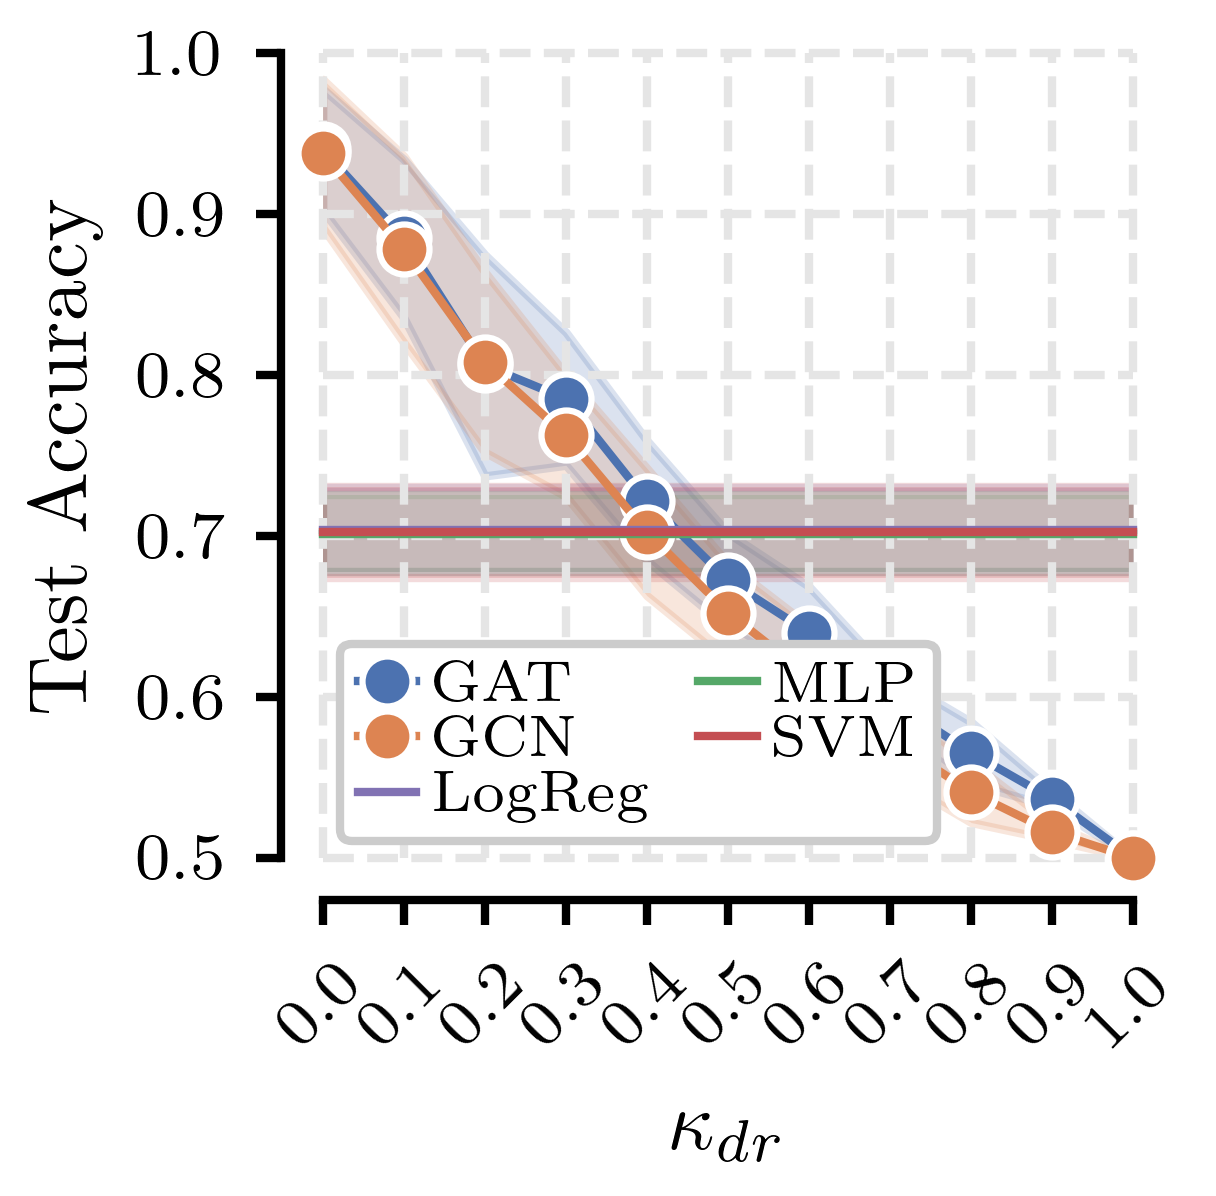

In [43]:
set_plot_params(style_name="pub_ltx")
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(1,1, figsize=set_size("ieee_1c", aspect_ratio=1, fraction=0.5))

sns.lineplot(
    data=res_dr_df.sort_values(by=["alg", "kappa"], ascending=True),
    x="kappa",
    y="acc",
    hue="alg",
    palette=colors_alg,
    style="alg",
    markers=markers_alg,
    markersize=6,
    dashes=False,
    errorbar="sd",
    clip_on=False,
    ax=ax
)

x_max = res_dr_df["kappa"].max()
print(x_max)

ax.set_xlabel("$\\kappa_{dr}$")
ax.set_xlim(0, x_max)
ax.set_xticks(res_dr_df["kappa"].unique())
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.5, 1)

leg = ax.legend(
    loc="lower left",
    framealpha=1.0,
    borderaxespad=0.3,
    borderpad=0.3,
    labelspacing=0.05,
    ncol=2,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=0.8,
)
for text in leg.get_texts():
    if text.get_text() == "alg":
        text.set_text("Method")
    if text.get_text() in ["Method", "informed"]:
        # text.set_fontweight("bold")
        text.set_text(r"\textbf{" + text.get_text().capitalize() + "}")

# despine
sns.despine(offset=5, trim=True)
for gl in ax.get_xgridlines() + ax.get_ygridlines():
    gl.set_clip_on(False)
    gl.set_in_layout(False)

fig.savefig("syn_node_dr_nodes.pdf", bbox_inches="tight", pad_inches=0)

plt.show()